In [2]:
import pandas as pd
df=pd.read_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/processed/merged_orders.csv')
df['order_purchase_timestamp']=pd.to_datetime(df['order_purchase_timestamp'])

In [3]:
# A "snapshot date" — we treat this as "today" for the purpose of measuring recency.
# Using the day after the last order in the dataset keeps this reproducible.
snapshot_date=df['order_purchase_timestamp'].max()+pd.Timedelta(days=1)

rfm=df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp',lambda x:(snapshot_date-x.max()).days),
    frequency=('order_id','nunique'),
    monetary=('payment_value','sum')
).reset_index()

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [4]:
print(rfm.shape)
rfm.describe()

(96096, 4)


,recency,frequency,monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,214.157343
std,153.414676,0.214384,644.891987
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,64.000000
50%,269.000000,1.000000,113.340000
75%,398.000000,1.000000,203.422500
max,773.000000,17.000000,109312.640000


In [5]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
rfm_scaled=scaler.fit_transform(rfm[['recency','frequency','monetary']])


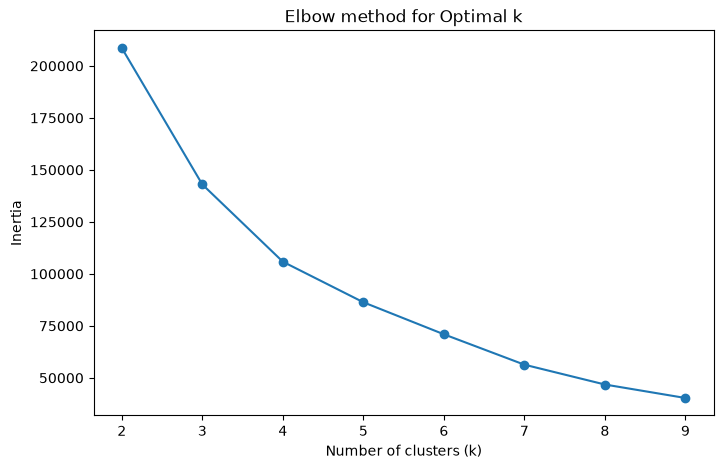

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia=[]
k_range=range(2,10)

for k in k_range:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range,inertia,marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method for Optimal k')
plt.show()

In [8]:
final_k = 4  

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
rfm['segment'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('segment')[['recency', 'frequency', 'monetary']].mean()

,recency,frequency,monetary
segment,,,
0,438.475838,1.000000,201.163096
1,178.114244,1.000000,199.178832
2,263.500000,1.272727,26932.410000
3,269.252923,2.115603,457.221527


In [9]:
rfm.to_csv('C:/Users/Asus/AppData/Local/GitHubDesktop/Shopsense/data/processed/customer_segments.csv', index=False)